# 05 - Spatial Dashboard and Policy Integration

## Alignment Notes
- **Objective**: translate crash risk outputs into a dashboard artifact for policy prioritization and stakeholder communication.
- **Primary question**: where should CDOT prioritize interventions based on spatial risk concentration and condition patterns?
- **Input data**:
  - `dataset/cleaned_data/risk_scores.csv` (condition-profile risk scoring output from Notebook 03)
  - `dataset/cleaned_data/train.csv` and `dataset/cleaned_data/test.csv` (full crash-level context for descriptive analysis)
  - `dataset/cleaned_data/cluster_labels.csv` (from Notebook 04)
- **Process in this notebook**:
  1. load and validate continuity from prior notebooks,
  2. build dashboard-ready aggregations,
  3. export static figures,
  4. generate a standalone HTML dashboard,
  5. export policy-ready CSV tables.
- **Output artifacts**:
  - `image/05_dashboard/chicago_crash_risk_dashboard.html`
  - `image/05_dashboard/*.png` (4 figures)
  - `dataset/cleaned_data/policy_priority_cells.csv`
  - `dataset/cleaned_data/dashboard_risk_cluster_table.csv`

This notebook uses the real cluster output from Notebook 04.


In [1]:
import json
from pathlib import Path
from urllib.error import URLError
from urllib.request import urlopen

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
from folium import plugins
from IPython.display import Markdown, display

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_ROOT = Path('dataset') if Path('dataset').exists() else Path('../dataset')
CLEAN_DIR = DATA_ROOT / 'cleaned_data'
IMAGE_DIR = Path('image/05_dashboard') if Path('image').exists() else Path('../image/05_dashboard')
REFERENCE_DIR = DATA_ROOT / 'reference'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
REFERENCE_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_DATA_AVAILABLE = True
RANDOM_STATE = 42


def save_fig(name: str):
    path = IMAGE_DIR / name
    plt.savefig(path, bbox_inches='tight', dpi=160)
    return path

print(f'Using data: {CLEAN_DIR.resolve()}')
print(f'Using image output: {IMAGE_DIR.resolve()}')
print(f'Using reference data: {REFERENCE_DIR.resolve()}')


Using data: /Users/rzrizaldy/CodeFolder/cmu_ml_midterm_project/dataset/cleaned_data
Using image output: /Users/rzrizaldy/CodeFolder/cmu_ml_midterm_project/image/05_dashboard
Using reference data: /Users/rzrizaldy/CodeFolder/cmu_ml_midterm_project/dataset/reference


## 1) Data Loading and Continuity Checks

In [2]:
risk_scores = pd.read_csv(CLEAN_DIR / 'risk_scores.csv')
train_df = pd.read_csv(CLEAN_DIR / 'train.csv')
test_df = pd.read_csv(CLEAN_DIR / 'test.csv')
all_crashes = pd.concat([train_df, test_df], ignore_index=True)

required_risk_cols = {
    'grid_lat', 'grid_lon', 'weather_bucket', 'lighting_bucket', 'time_bucket', 'speed_bucket',
    'crash_count', 'severe_count', 'severe_rate', 'predicted_severe_rate', 'risk_score', 'rank', 'recommendation'
}
required_crash_cols = {
    'CRASH_DATE', 'LATITUDE', 'LONGITUDE', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'is_severe'
}

missing_risk = required_risk_cols - set(risk_scores.columns)
missing_train = required_crash_cols - set(train_df.columns)
missing_test = required_crash_cols - set(test_df.columns)
missing_all = required_crash_cols - set(all_crashes.columns)
assert not missing_risk, f'Missing risk columns: {missing_risk}'
assert not missing_train, f'Missing train columns: {missing_train}'
assert not missing_test, f'Missing test columns: {missing_test}'
assert not missing_all, f'Missing combined columns: {missing_all}'

all_crashes['CRASH_DATE'] = pd.to_datetime(all_crashes['CRASH_DATE'], errors='coerce')

print(f'risk_scores shape: {risk_scores.shape}')
print(f'train shape: {train_df.shape}')
print(f'test shape: {test_df.shape}')
print(f'all_crashes shape: {all_crashes.shape}')
print(f'risk_score range: {risk_scores.risk_score.min():.4f} to {risk_scores.risk_score.max():.4f}')

risk_scores shape: (91616, 13)
train shape: (246221, 24)
test shape: (82274, 24)
all_crashes shape: (328495, 24)
risk_score range: 0.0108 to 0.2762


In [3]:
grid_cells = (
    risk_scores
    .groupby(['grid_lat', 'grid_lon'], as_index=False)
    .agg(
        risk_score=('risk_score', 'mean'),
        max_risk_score=('risk_score', 'max'),
        crash_count=('crash_count', 'sum'),
        severe_count=('severe_count', 'sum')
    )
)
grid_cells['severe_rate'] = np.where(grid_cells['crash_count'] > 0, grid_cells['severe_count'] / grid_cells['crash_count'], 0.0)

assert CLUSTER_DATA_AVAILABLE, 'Notebook 05 requires real cluster labels from notebook 04.'
cluster_df = pd.read_csv(CLEAN_DIR / 'cluster_labels.csv')
expected = {'grid_lat', 'grid_lon', 'cluster_kmeans', 'cluster_dbscan', 'is_high_risk_cluster'}
assert expected.issubset(cluster_df.columns), f'cluster_labels.csv needs columns: {expected}'

grid_cells = grid_cells.merge(
    cluster_df[['grid_lat', 'grid_lon', 'cluster_kmeans', 'cluster_dbscan', 'is_high_risk_cluster']],
    on=['grid_lat', 'grid_lon'],
    how='left'
)

missing_clusters = grid_cells['cluster_kmeans'].isna().sum()
assert missing_clusters == 0, f'Missing cluster labels for {missing_clusters} grid cells.'

grid_cells['cluster_kmeans'] = grid_cells['cluster_kmeans'].astype(int)
grid_cells['cluster_dbscan'] = grid_cells['cluster_dbscan'].astype(int)
grid_cells['is_high_risk_cluster'] = grid_cells['is_high_risk_cluster'].astype(int)

print(f'Unique grid cells: {len(grid_cells):,}')
print('Cluster mode: notebook 04 exported clusters')


Unique grid cells: 2,495
Cluster mode: placeholder quantile clusters


### 1.1 Neighborhood Context for Real-Map Exploration

This subsection adds Chicago community-area boundaries so crash patterns can be interpreted using real neighborhood names, not only latitude and longitude.

In [4]:
community_geojson_path = REFERENCE_DIR / 'chicago_community_areas.geojson'

if not community_geojson_path.exists():
    geojson_urls = [
        'https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=5000',
    ]
    downloaded = False
    for url in geojson_urls:
        try:
            with urlopen(url, timeout=30) as resp:
                payload = resp.read()
            community_geojson_path.write_bytes(payload)
            downloaded = True
            break
        except URLError:
            continue
    assert downloaded, 'Could not download Chicago community-area GeoJSON. Please check network or provide local file.'

community_areas = gpd.read_file(community_geojson_path).to_crs(epsg=4326)
community_areas['community'] = community_areas['community'].str.title()
community_areas = community_areas[['community', 'geometry']].copy()

community_areas_simple = community_areas.copy()
community_areas_simple['geometry'] = community_areas_simple['geometry'].simplify(0.00025, preserve_topology=True)

display(community_areas.head(3))

,community,geometry
0,Rogers Park,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,West Ridge,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."
2,Uptown,"MULTIPOLYGON (((-87.64102 41.9548, -87.644 41...."


In [5]:
grid_points = gpd.GeoDataFrame(
    grid_cells[['grid_lat', 'grid_lon']].copy(),
    geometry=gpd.points_from_xy(grid_cells['grid_lon'], grid_cells['grid_lat']),
    crs='EPSG:4326'
)

grid_with_community = gpd.sjoin(
    grid_points,
    community_areas[['community', 'geometry']],
    how='left',
    predicate='within'
).drop(columns=['index_right'])

grid_cells = grid_cells.merge(
    grid_with_community[['grid_lat', 'grid_lon', 'community']],
    on=['grid_lat', 'grid_lon'],
    how='left'
)
grid_cells['community'] = grid_cells['community'].fillna('Unassigned')

risk_scores = risk_scores.merge(
    grid_cells[['grid_lat', 'grid_lon', 'community']],
    on=['grid_lat', 'grid_lon'],
    how='left'
)
risk_scores['community'] = risk_scores['community'].fillna('Unassigned')

neighborhood_stats = (
    risk_scores
    .groupby('community', as_index=False)
    .agg(
        crash_count=('crash_count', 'sum'),
        severe_count=('severe_count', 'sum'),
        avg_risk_score=('risk_score', 'mean'),
        profile_count=('risk_score', 'size')
    )
)
neighborhood_stats['severe_rate_pct'] = np.where(
    neighborhood_stats['crash_count'] > 0,
    100 * neighborhood_stats['severe_count'] / neighborhood_stats['crash_count'],
    np.nan
)
neighborhood_stats = neighborhood_stats.sort_values('crash_count', ascending=False)

neighborhood_stats.head(12)

,community,crash_count,severe_count,avg_risk_score,profile_count,severe_rate_pct
49,Near West Side,16138,262,0.020221,3216,1.623497
47,Near North Side,15011,181,0.020902,2425,1.205782
5,Austin,13763,280,0.019561,3565,2.034440
76,West Town,10460,159,0.019201,2489,1.520076
41,Loop,9609,148,0.022090,1445,1.540223
40,Logan Square,9102,126,0.019097,2129,1.384311
8,Belmont Cragin,7850,102,0.018578,2074,1.299363
32,Humboldt Park,7394,133,0.019546,1825,1.798756
37,Lake View,7088,97,0.019363,1702,1.368510
66,Unassigned,6906,127,0.016626,2706,1.838981


In [6]:
top3_crash = neighborhood_stats.head(3)
top3_severe = neighborhood_stats.sort_values('severe_rate_pct', ascending=False).head(3)

insight_text = (
    f"**Descriptive Neighborhood Insights (No ML):**\n\n"
    f"- Crash volume is concentrated in a small set of neighborhoods. Top 3 by crash count are "
    f"**{top3_crash.iloc[0]['community']}**, **{top3_crash.iloc[1]['community']}**, and **{top3_crash.iloc[2]['community']}**.\n"
    f"- Severe-rate hotspots are different from volume hotspots. Top 3 by severe rate are "
    f"**{top3_severe.iloc[0]['community']}**, **{top3_severe.iloc[1]['community']}**, and **{top3_severe.iloc[2]['community']}**.\n"
    f"- Operationally, this supports two lenses: high-volume neighborhoods for broad safety management, "
    f"and high-severity neighborhoods for targeted intervention design."
)

display(Markdown(insight_text))
display(neighborhood_stats.head(15))

**Descriptive Neighborhood Insights (No ML):**

- Crash volume is concentrated in a small set of neighborhoods. Top 3 by crash count are **Near West Side**, **Near North Side**, and **Austin**.
- Severe-rate hotspots are different from volume hotspots. Top 3 by severe rate are **Douglas**, **Avalon Park**, and **Roseland**.
- Operationally, this supports two lenses: high-volume neighborhoods for broad safety management, and high-severity neighborhoods for targeted intervention design.

,community,crash_count,severe_count,avg_risk_score,profile_count,severe_rate_pct
49,Near West Side,16138,262,0.020221,3216,1.623497
47,Near North Side,15011,181,0.020902,2425,1.205782
5,Austin,13763,280,0.019561,3565,2.034440
76,West Town,10460,159,0.019201,2489,1.520076
41,Loop,9609,148,0.022090,1445,1.540223
40,Logan Square,9102,126,0.019097,2129,1.384311
8,Belmont Cragin,7850,102,0.018578,2074,1.299363
32,Humboldt Park,7394,133,0.019546,1825,1.798756
37,Lake View,7088,97,0.019363,1702,1.368510
66,Unassigned,6906,127,0.016626,2706,1.838981


In [7]:
map_center = [float(all_crashes['LATITUDE'].mean()), float(all_crashes['LONGITUDE'].mean())]

context_map = folium.Map(
    location=map_center,
    zoom_start=10,
    tiles='CartoDB positron',
    control_scale=True
)

community_map_df = community_areas_simple.merge(neighborhood_stats, on='community', how='left')
community_map_df['crash_count'] = community_map_df['crash_count'].fillna(0).astype(int)
community_map_df['severe_rate_pct'] = community_map_df['severe_rate_pct'].fillna(0.0)
community_map_df['avg_risk_score'] = community_map_df['avg_risk_score'].fillna(0.0)

folium.Choropleth(
    geo_data=community_map_df.to_json(),
    data=community_map_df,
    columns=['community', 'crash_count'],
    key_on='feature.properties.community',
    fill_color='YlOrRd',
    fill_opacity=0.65,
    line_opacity=0.35,
    nan_fill_color='#f2f2f2',
    legend_name='Crash count by neighborhood (aggregated profiles)'
).add_to(context_map)

folium.GeoJson(
    community_map_df,
    name='Neighborhood boundary and stats',
    style_function=lambda _: {'fillOpacity': 0.0, 'weight': 0.8, 'color': '#666'},
    tooltip=folium.GeoJsonTooltip(
        fields=['community', 'crash_count', 'severe_rate_pct', 'avg_risk_score'],
        aliases=['Neighborhood', 'Crash count', 'Severe rate (%)', 'Avg risk score'],
        localize=True,
        sticky=False,
        labels=True,
    ),
).add_to(context_map)

# Derive tier from recommendation for map filtering, independent from later cells.
def recommendation_to_tier_local(rec: str) -> str:
    if isinstance(rec, str):
        if rec.startswith('PRIORITY'):
            return 'PRIORITY'
        if rec.startswith('HIGH'):
            return 'HIGH'
        if rec.startswith('MODERATE'):
            return 'MODERATE'
    return 'STANDARD'


def mode_or_unknown(series: pd.Series) -> str:
    mode = series.dropna().mode()
    if len(mode) > 0:
        return str(mode.iloc[0])
    return 'UNKNOWN'


map_points = risk_scores[['grid_lat', 'grid_lon', 'community', 'recommendation', 'crash_count', 'severe_count', 'risk_score']].copy()
map_points['tier'] = map_points['recommendation'].map(recommendation_to_tier_local)
map_points = (
    map_points
    .groupby(['grid_lat', 'grid_lon', 'community', 'tier'], as_index=False)
    .agg(
        crash_count=('crash_count', 'sum'),
        severe_count=('severe_count', 'sum'),
        risk_score=('risk_score', 'mean')
    )
)
map_points['severe_rate_pct'] = np.where(map_points['crash_count'] > 0, 100 * map_points['severe_count'] / map_points['crash_count'], 0.0)

crash_geo_context = (
    all_crashes[['LATITUDE', 'LONGITUDE', 'TRAFFICWAY_TYPE']]
    .dropna(subset=['LATITUDE', 'LONGITUDE'])
    .assign(
        grid_lat=lambda d: d['LATITUDE'].round(2),
        grid_lon=lambda d: d['LONGITUDE'].round(2)
    )
)

point_context = (
    crash_geo_context
    .groupby(['grid_lat', 'grid_lon'], as_index=False)
    .agg(dominant_trafficway=('TRAFFICWAY_TYPE', mode_or_unknown))
)

map_points = map_points.merge(point_context, on=['grid_lat', 'grid_lon'], how='left')
map_points['dominant_trafficway'] = map_points['dominant_trafficway'].fillna('UNKNOWN')
map_points['location_label'] = (
    map_points['dominant_trafficway'].str.replace('_', ' ', regex=False).str.title()
    + ' | approx ('
    + map_points['grid_lat'].round(4).astype(str)
    + ', '
    + map_points['grid_lon'].round(4).astype(str)
    + ')'
)

priority_high = map_points[map_points['tier'].isin(['PRIORITY', 'HIGH'])]
others = map_points[~map_points['tier'].isin(['PRIORITY', 'HIGH'])]
map_points_sample = pd.concat([
    priority_high,
    others.sample(n=min(1200, len(others)), random_state=RANDOM_STATE, weights=others['crash_count'].clip(lower=1))
], ignore_index=True)

tier_color = {
    'PRIORITY': '#dc2626',
    'HIGH': '#ea580c',
    'MODERATE': '#ca8a04',
    'STANDARD': '#16a34a'
}

for tier_name in ['PRIORITY', 'HIGH', 'MODERATE', 'STANDARD']:
    fg = folium.FeatureGroup(name=f'{tier_name} grid cells', show=(tier_name in ['PRIORITY', 'HIGH']))
    sub = map_points_sample[map_points_sample['tier'] == tier_name]
    for r in sub.itertuples(index=False):
        folium.CircleMarker(
            location=[r.grid_lat, r.grid_lon],
            radius=max(2, min(7, np.sqrt(r.crash_count))),
            color=tier_color[tier_name],
            fill=True,
            fill_opacity=0.55,
            weight=0.8,
            popup=(
                f"Neighborhood: {r.community}<br>"
                f"Tier: {r.tier}<br>"
                f"Crashes: {int(r.crash_count)}<br>"
                f"Severe rate: {r.severe_rate_pct:.2f}%<br>"
                f"Road context: {str(r.dominant_trafficway).replace('_', ' ').title()}<br>"
                f"Approx point: ({r.grid_lat:.4f}, {r.grid_lon:.4f})<br>"
                f"Risk score: {r.risk_score:.4f}"
            )
        ).add_to(fg)
    fg.add_to(context_map)

search_layer = folium.GeoJson(
    community_map_df[['community', 'geometry']].to_json(),
    name='Neighborhood search source',
    show=False,
)
search_layer.add_to(context_map)

plugins.Search(
    layer=search_layer,
    geom_type='Polygon',
    search_label='community',
    placeholder='Search neighborhood',
    collapsed=False,
).add_to(context_map)

plugins.Fullscreen(position='topright').add_to(context_map)
plugins.MiniMap(toggle_display=True).add_to(context_map)
folium.LayerControl(collapsed=False).add_to(context_map)

context_map

## 2) Dashboard Aggregations

In [8]:
kpis = {
    'total_crashes': int(all_crashes.shape[0]),
    'severe_rate_pct': float(all_crashes['is_severe'].mean() * 100),
    'high_risk_zones': int(risk_scores.loc[risk_scores['rank'] <= 200, ['grid_lat', 'grid_lon']].drop_duplicates().shape[0]),
    'max_risk_score': float(risk_scores['risk_score'].max())
}

kpi_df = pd.DataFrame([kpis])
kpi_df

,total_crashes,severe_rate_pct,high_risk_zones,max_risk_score
0,328495,1.614028,181,0.27619


In [9]:
tier_labels = ['STANDARD', 'MODERATE', 'HIGH', 'PRIORITY']
grid_cells['tier'] = pd.qcut(
    grid_cells['risk_score'].rank(method='first'),
    q=4,
    labels=tier_labels
).astype(str)

priority_high = grid_cells[grid_cells['tier'].isin(['PRIORITY', 'HIGH'])].copy()
rest = grid_cells[~grid_cells['tier'].isin(['PRIORITY', 'HIGH'])].copy()

remaining_n = max(0, 800 - len(priority_high))
if remaining_n > 0 and len(rest) > 0:
    rest_sample = rest.sample(
        n=min(remaining_n, len(rest)),
        random_state=RANDOM_STATE,
        weights=rest['crash_count'].clip(lower=1)
    )
else:
    rest_sample = rest.head(0)

scatter_df = pd.concat([priority_high, rest_sample], ignore_index=True).drop_duplicates(['grid_lat', 'grid_lon'])
scatter_df = scatter_df.rename(columns={'grid_lat': 'lat', 'grid_lon': 'lon'})

scatter_df[['lat', 'lon', 'risk_score', 'crash_count', 'tier']].head()

,lat,lon,risk_score,crash_count,tier
0,41.645,-87.560,0.018280,3,HIGH
1,41.645,-87.545,0.018140,17,HIGH
2,41.645,-87.540,0.017158,25,HIGH
3,41.650,-87.550,0.021525,20,PRIORITY
4,41.650,-87.540,0.019962,37,PRIORITY


In [10]:
wl_agg = (
    risk_scores
    .groupby(['weather_bucket', 'lighting_bucket'], as_index=False)
    .agg(crash_count=('crash_count', 'sum'), severe_count=('severe_count', 'sum'))
)
wl_agg['severe_rate_pct'] = np.where(wl_agg['crash_count'] > 0, 100 * wl_agg['severe_count'] / wl_agg['crash_count'], np.nan)

weather_order = sorted(wl_agg['weather_bucket'].dropna().unique())
lighting_order = sorted(wl_agg['lighting_bucket'].dropna().unique())

wl_pivot = wl_agg.pivot(index='weather_bucket', columns='lighting_bucket', values='severe_rate_pct').reindex(index=weather_order, columns=lighting_order)
wl_pivot

lighting_bucket,DARK_LIT,DARK_UNLIT,DAWN_DUSK,DAYLIGHT,OTHER
weather_bucket,,,,,
CLEAR,2.621771,1.977878,1.919787,1.451558,0.420440
OTHER,1.450971,0.917431,1.291513,0.852799,0.344540
RAIN,2.681783,2.407117,2.159827,1.394224,0.680272
SNOW_ICE,1.748512,1.788618,1.304348,0.942951,0.000000


In [11]:
day_map = {
    1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'
}

temporal = (
    all_crashes
    .dropna(subset=['CRASH_DAY_OF_WEEK', 'CRASH_HOUR'])
    .assign(day_label=lambda d: d['CRASH_DAY_OF_WEEK'].astype(int).map(day_map))
    .groupby(['day_label', 'CRASH_HOUR'], as_index=False)['is_severe'].mean()
)
temporal['severe_rate_pct'] = temporal['is_severe'] * 100

day_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
hour_order = list(range(24))

temporal_pivot = temporal.pivot(index='day_label', columns='CRASH_HOUR', values='severe_rate_pct').reindex(index=day_order, columns=hour_order)
temporal_pivot.head()

CRASH_HOUR,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_label,,,,,,,,,,,,,,,,,,,,,
Sun,2.607362,3.215768,3.701626,2.608180,3.684211,2.000000,1.790634,1.767677,2.217295,1.962323,...,1.713830,1.624216,1.806046,1.400906,1.777575,2.551834,1.824603,3.454658,2.819807,2.214930
Mon,2.801724,3.018373,2.689076,3.006012,2.049180,2.531646,1.358696,0.925926,0.921356,1.258155,...,1.377688,1.159794,1.418250,1.371862,1.535974,2.212138,1.716738,2.411714,2.812803,2.681992
Tue,3.104575,3.017241,3.100775,2.027027,2.201258,1.974865,1.861702,1.137980,1.108900,0.994644,...,1.003886,1.362199,1.142422,1.234237,1.779603,2.031488,1.681237,2.795527,2.613746,3.699284
Wed,2.071006,1.840491,3.856041,3.169014,2.023121,1.688555,2.077922,1.242938,1.055100,0.895037,...,1.549907,1.005673,1.037613,1.341243,1.380007,1.633045,2.672751,2.182385,2.372881,3.027027
Thu,1.358696,2.268431,1.456311,3.592814,3.201970,2.184874,2.038925,1.179941,1.089517,1.070840,...,1.055662,0.880626,1.208981,1.213843,1.679289,2.213667,2.196461,0.843289,2.142857,3.038674


In [12]:
def build_condition_severe_table(group_col: str):
    tab = (
        risk_scores
        .groupby(group_col, as_index=False)
        .agg(
            crash_count=('crash_count', 'sum'),
            severe_count=('severe_count', 'sum')
        )
    )
    tab['severe_rate_pct'] = np.where(
        tab['crash_count'] > 0,
        100 * tab['severe_count'] / tab['crash_count'],
        0.0
    )
    return tab.sort_values(['severe_rate_pct', 'crash_count'], ascending=[False, False])

cond_weather = build_condition_severe_table('weather_bucket')
cond_light = build_condition_severe_table('lighting_bucket')
cond_time = build_condition_severe_table('time_bucket')
cond_speed = build_condition_severe_table('speed_bucket')

condition_tables = {
    'weather': cond_weather,
    'lighting': cond_light,
    'time': cond_time,
    'speed': cond_speed,
}

for name, tab in condition_tables.items():
    print(name, 'rows:', len(tab))

cond_weather[['weather_bucket', 'crash_count', 'severe_count', 'severe_rate_pct']].head()

weather rows: 4
lighting rows: 5
time rows: 4
speed rows: 5


,weather_bucket,crash_count,severe_count,severe_rate_pct
2,RAIN,27435,531,1.935484
0,CLEAR,254715,4402,1.728206
3,SNOW_ICE,8200,104,1.268293
1,OTHER,38145,265,0.694718


In [13]:
def recommendation_to_tier(rec: str) -> str:
    if isinstance(rec, str):
        if rec.startswith('PRIORITY'):
            return 'PRIORITY'
        if rec.startswith('HIGH'):
            return 'HIGH'
        if rec.startswith('MODERATE'):
            return 'MODERATE'
    return 'STANDARD'

risk_scores['tier'] = risk_scores['recommendation'].map(recommendation_to_tier)

neighborhood_tier_stats = (
    risk_scores
    .groupby(['tier', 'community'], as_index=False)
    .agg(
        crash_count=('crash_count', 'sum'),
        severe_count=('severe_count', 'sum'),
        avg_risk_score=('risk_score', 'mean')
    )
)
neighborhood_tier_stats['severe_rate_pct'] = np.where(
    neighborhood_tier_stats['crash_count'] > 0,
    100 * neighborhood_tier_stats['severe_count'] / neighborhood_tier_stats['crash_count'],
    0.0
)

dominant_tier = (
    neighborhood_tier_stats
    .sort_values(['community', 'severe_rate_pct', 'crash_count'], ascending=[True, False, False])
    .drop_duplicates('community')
    [['community', 'tier']]
    .rename(columns={'tier': 'dominant_tier'})
)

neighborhood_severe_rank = (
    neighborhood_stats
    .merge(dominant_tier, on='community', how='left')
    .assign(dominant_tier=lambda d: d['dominant_tier'].fillna('STANDARD'))
    .sort_values(['severe_rate_pct', 'crash_count'], ascending=[False, False])
    [['community', 'crash_count', 'severe_count', 'severe_rate_pct', 'avg_risk_score', 'dominant_tier']]
)

sankey_df = (
    risk_scores
    .groupby(['tier', 'recommendation'], as_index=False)
    .agg(value=('crash_count', 'sum'))
)

threshold_rows = []
total_severe = max(risk_scores['severe_count'].sum(), 1)
for cutoff in [50, 100, 200, 500, 1000, 2000, 5000]:
    sub = risk_scores[risk_scores['rank'] <= cutoff]
    threshold_rows.append({
        'rank_cutoff': cutoff,
        'zone_count': int(sub[['grid_lat', 'grid_lon']].drop_duplicates().shape[0]),
        'severe_capture_pct': float(100 * sub['severe_count'].sum() / total_severe)
    })
threshold_df = pd.DataFrame(threshold_rows)

risk_vals = risk_scores['risk_score'].dropna().to_numpy()
if len(risk_vals) > 1:
    x_grid = np.linspace(risk_vals.min(), risk_vals.max(), 140)
    std = np.std(risk_vals, ddof=1)
    bw = 1.06 * std * (len(risk_vals) ** (-1/5)) if std > 0 else max((risk_vals.max() - risk_vals.min()) / 30, 1e-4)
    z = (x_grid[:, None] - risk_vals[None, :]) / max(bw, 1e-6)
    density = np.exp(-0.5 * z * z).sum(axis=1) / (len(risk_vals) * max(bw, 1e-6) * np.sqrt(2 * np.pi))
else:
    x_grid = np.array([risk_vals[0] if len(risk_vals) == 1 else 0.0])
    density = np.array([1.0])

hist_df = pd.DataFrame({
    'x': x_grid,
    'density': density
})

top_profiles = risk_scores.sort_values('rank').head(50).copy()
top_profiles['severe_rate_pct'] = top_profiles['severe_rate'] * 100

tier_cards = (
    grid_cells
    .groupby('tier', as_index=False)
    .agg(cell_count=('tier', 'count'), avg_risk=('risk_score', 'mean'), crash_count=('crash_count', 'sum'))
    .set_index('tier')
    .reindex(['PRIORITY', 'HIGH', 'MODERATE', 'STANDARD'])
    .reset_index()
)

threshold_df

# Daily descriptive trend for dashboard timeline (EDA-first context)
daily_trend = (
    all_crashes.dropna(subset=['CRASH_DATE'])
    .assign(crash_day=lambda d: d['CRASH_DATE'].dt.floor('D'))
    .groupby('crash_day', as_index=False)
    .agg(
        total_crashes=('is_severe', 'size'),
        severe_crashes=('is_severe', 'sum')
    )
    .sort_values('crash_day')
)
daily_trend['severe_rate_pct'] = np.where(
    daily_trend['total_crashes'] > 0,
    100 * daily_trend['severe_crashes'] / daily_trend['total_crashes'],
    0.0
)

# Detail tables for polygon cross-filter in timeline and weather views.
grid_context_lookup = grid_cells[['grid_lat', 'grid_lon', 'community', 'tier']].drop_duplicates()

crash_with_context = (
    all_crashes
    .dropna(subset=['CRASH_DATE', 'LATITUDE', 'LONGITUDE'])
    .assign(
        grid_lat=lambda d: d['LATITUDE'].round(2),
        grid_lon=lambda d: d['LONGITUDE'].round(2),
        crash_day=lambda d: d['CRASH_DATE'].dt.floor('D')
    )
    .merge(grid_context_lookup, on=['grid_lat', 'grid_lon'], how='left')
)
crash_with_context['community'] = crash_with_context['community'].fillna('Unassigned')
crash_with_context['tier'] = crash_with_context['tier'].fillna('STANDARD')

timeline_detail = (
    crash_with_context
    .groupby(['crash_day', 'community', 'tier'], as_index=False)
    .agg(
        total_crashes=('is_severe', 'size'),
        severe_crashes=('is_severe', 'sum')
    )
)

wl_detail = (
    risk_scores
    .groupby(['community', 'tier', 'weather_bucket', 'lighting_bucket'], as_index=False)
    .agg(
        crash_count=('crash_count', 'sum'),
        severe_count=('severe_count', 'sum')
    )
)
wl_detail['severe_rate_pct'] = np.where(
    wl_detail['crash_count'] > 0,
    100 * wl_detail['severe_count'] / wl_detail['crash_count'],
    0.0
)

eligible_severe = neighborhood_stats[neighborhood_stats['crash_count'] >= 100].sort_values('severe_rate_pct', ascending=False)
insight_summary = {
    'top_volume': neighborhood_stats.head(3)['community'].tolist(),
    'top_severe_rate': eligible_severe.head(3)['community'].tolist(),
    'peak_day': str(daily_trend.loc[daily_trend['total_crashes'].idxmax(), 'crash_day'].date()),
    'peak_crashes': int(daily_trend['total_crashes'].max()),
    'daily_avg_crashes': float(daily_trend['total_crashes'].mean())
}


## 3) Matplotlib Visualizations (saved to `image/05_dashboard/`)

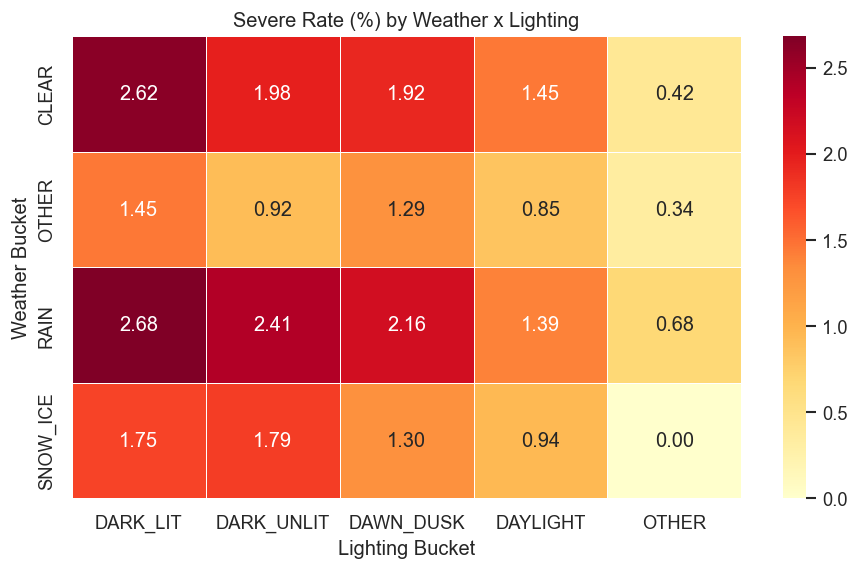

PosixPath('../image/05_dashboard/01_weather_lighting_heatmap.png')

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(wl_pivot, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.4, ax=ax)
ax.set_title('Severe Rate (%) by Weather x Lighting')
ax.set_xlabel('Lighting Bucket')
ax.set_ylabel('Weather Bucket')
path_2 = save_fig('01_weather_lighting_heatmap.png')
plt.show()
path_2

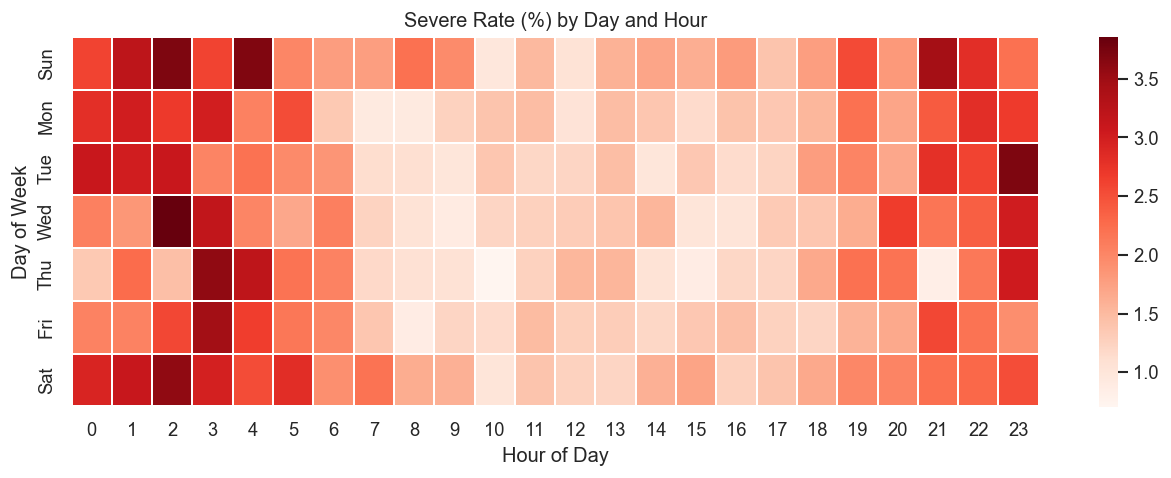

PosixPath('../image/05_dashboard/02_temporal_heatmap.png')

In [15]:
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(temporal_pivot, cmap='Reds', linewidths=0.2, ax=ax)
ax.set_title('Severe Rate (%) by Day and Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
path_3 = save_fig('02_temporal_heatmap.png')
plt.show()
path_3

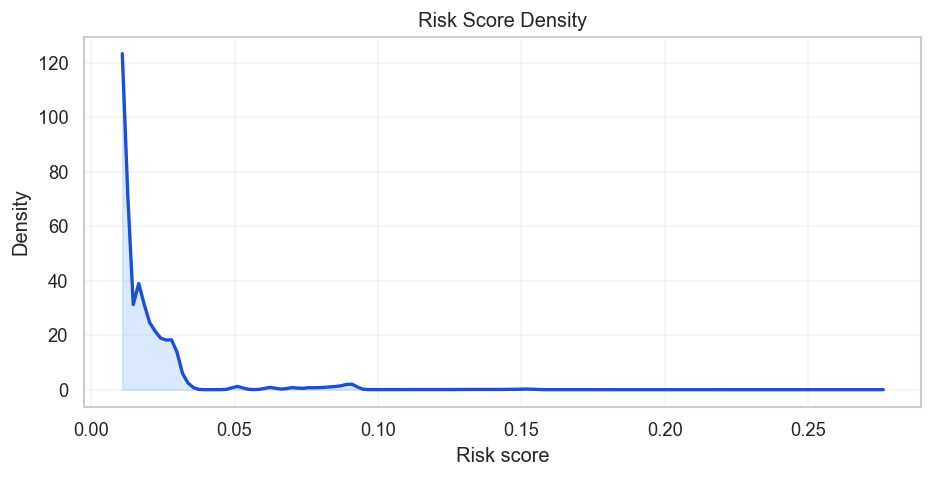

PosixPath('../image/05_dashboard/03_risk_distribution.png')

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hist_df['x'], hist_df['density'], color='#1d4ed8', linewidth=2)
ax.fill_between(hist_df['x'], hist_df['density'], color='#93c5fd', alpha=0.35)
ax.set_title('Risk Score Density')
ax.set_xlabel('Risk score')
ax.set_ylabel('Density')
ax.grid(alpha=0.2)
path_4 = save_fig('03_risk_distribution.png')
plt.show()
path_4

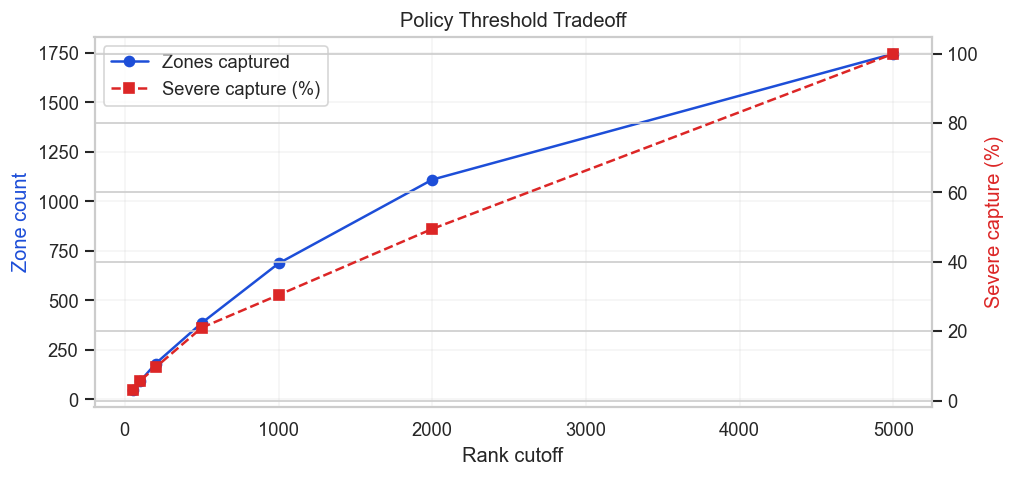

PosixPath('../image/05_dashboard/04_policy_threshold.png')

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(threshold_df['rank_cutoff'], threshold_df['zone_count'], marker='o', label='Zones captured', color='#1d4ed8')
ax2 = ax.twinx()
ax2.plot(threshold_df['rank_cutoff'], threshold_df['severe_capture_pct'], marker='s', linestyle='--',
         label='Severe capture (%)', color='#dc2626')

ax.set_title('Policy Threshold Tradeoff')
ax.set_xlabel('Rank cutoff')
ax.set_ylabel('Zone count', color='#1d4ed8')
ax2.set_ylabel('Severe capture (%)', color='#dc2626')
ax.grid(alpha=0.2)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

path_5 = save_fig('04_policy_threshold.png')
plt.show()
path_5

## 4) Static HTML Dashboard Generation

In [18]:
# Compact JSON blobs for embedding

wl_blob = json.dumps({
    'rows': list(wl_pivot.index),
    'cols': list(wl_pivot.columns),
    'vals': [[None if pd.isna(v) else float(v) for v in row] for row in wl_pivot.values]
}, separators=(',', ':'))

temporal_blob = json.dumps({
    'days': list(temporal_pivot.index),
    'hours': [int(h) for h in temporal_pivot.columns],
    'vals': [[None if pd.isna(v) else float(v) for v in row] for row in temporal_pivot.values]
}, separators=(',', ':'))

condition_blob = json.dumps({
    'weather': cond_weather.to_dict('records'),
    'lighting': cond_light.to_dict('records'),
    'time': cond_time.to_dict('records'),
    'speed': cond_speed.to_dict('records')
}, separators=(',', ':'))

sankey_blob = json.dumps(sankey_df.to_dict('records'), separators=(',', ':'))
threshold_blob = json.dumps(threshold_df.to_dict('records'), separators=(',', ':'))
hist_blob = json.dumps(hist_df.to_dict('records'), separators=(',', ':'))
top_blob = json.dumps(top_profiles[['rank', 'grid_lat', 'grid_lon', 'community', 'weather_bucket', 'lighting_bucket', 'time_bucket', 'speed_bucket', 'crash_count', 'severe_rate_pct', 'risk_score', 'recommendation']].to_dict('records'), separators=(',', ':'))
neighborhood_blob = json.dumps(
    neighborhood_severe_rank.to_dict('records'),
    separators=(',', ':')
)
map_points_blob = json.dumps([
    {
        'la': round(float(r.grid_lat), 4),
        'lo': round(float(r.grid_lon), 4),
        'n': r.community,
        't': r.tier,
        'c': int(r.crash_count),
        's': round(float(r.severe_rate_pct), 2),
        'tw': str(r.dominant_trafficway),
        'loc': r.location_label
    }
    for r in map_points_sample.itertuples(index=False)
], separators=(',', ':'))

daily_blob = json.dumps([
    {
        'd': str(r.crash_day.date()),
        'c': int(r.total_crashes),
        's': int(r.severe_crashes),
        'sr': round(float(r.severe_rate_pct), 3)
    }
    for r in daily_trend.itertuples(index=False)
], separators=(',', ':'))

daily_detail_blob = json.dumps([
    {
        'd': str(r.crash_day.date()),
        'n': r.community,
        't': r.tier,
        'c': int(r.total_crashes),
        's': int(r.severe_crashes)
    }
    for r in timeline_detail.itertuples(index=False)
], separators=(',', ':'))

wl_detail_blob = json.dumps([
    {
        'n': r.community,
        't': r.tier,
        'w': r.weather_bucket,
        'l': r.lighting_bucket,
        'c': int(r.crash_count),
        's': int(r.severe_count),
        'sr': round(float(r.severe_rate_pct), 3)
    }
    for r in wl_detail.itertuples(index=False)
], separators=(',', ':'))

neigh_geo_blob = community_map_df[['community', 'crash_count', 'severe_rate_pct', 'avg_risk_score', 'geometry']].to_json()
insight_blob = json.dumps(insight_summary, separators=(',', ':'))

kpi_blob = json.dumps(kpis, separators=(',', ':'))
tier_blob = json.dumps(tier_cards.to_dict('records'), separators=(',', ':'))

for name, blob in [
    ('weather_lighting', wl_blob), ('temporal', temporal_blob),
    ('condition', condition_blob), ('sankey', sankey_blob), ('threshold', threshold_blob),
    ('hist', hist_blob), ('top', top_blob), ('neighborhood', neighborhood_blob),
    ('map_points', map_points_blob), ('daily', daily_blob), ('daily_detail', daily_detail_blob),
    ('wl_detail', wl_detail_blob), ('neigh_geo', neigh_geo_blob),
    ('insight', insight_blob), ('kpi', kpi_blob), ('tier', tier_blob)
]:
    print(f'{name:16s}: {len(blob)/1024:7.2f} KB')


weather_lighting:    0.47 KB
temporal        :    3.20 KB
condition       :    1.86 KB
sankey          :    0.40 KB
threshold       :    0.51 KB
hist            :    7.67 KB
top             :   16.70 KB
neighborhood    :   12.53 KB
map_points      :  181.82 KB
daily           :   47.02 KB
daily_detail    : 8455.70 KB
wl_detail       :  147.12 KB
neigh_geo       :   93.95 KB
insight         :    0.19 KB
kpi             :    0.12 KB
tier            :    0.35 KB


In [19]:
template = '''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1.0" />
  <title>Chicago Crash Risk Dashboard</title>
  <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
  <script src="https://cdn.jsdelivr.net/npm/chartjs-plugin-datalabels@2"></script>
  <script src="https://cdn.jsdelivr.net/npm/d3@7"></script>
  <script src="https://cdn.jsdelivr.net/npm/d3-sankey@0.12.3"></script>
  <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" integrity="sha256-p4NxAoJBhIIN+hmNHrzRCf9tD/miZyoHS5obTRR9BMY=" crossorigin=""/>
  <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js" integrity="sha256-20nQCchB9co0qIjJZRGuk2/Z9VM+kNiyxNV1lvTlZBo=" crossorigin=""></script>
  <style>
    :root {
      --bg:#f4f7fb; --card:#ffffff; --border:#d6e0eb; --border-dark:#b8c7d8;
      --text:#1f2937; --text-muted:#5b6b80; --shadow:rgba(15,23,42,0.08);
      --tableau-blue:#4e79a7; --tableau-orange:#f28e2b; --tableau-red:#e15759; --tableau-teal:#76b7b2;
      --tableau-green:#59a14f; --tableau-yellow:#edc948; --tableau-purple:#b07aa1; --tableau-grey:#bab0ab;
      --critical:#d62728; --high:#ff7f0e; --moderate:#bcbd22; --standard:#2ca02c;
    }
    * { box-sizing:border-box; margin:0; padding:0; }
    body { font-family:'Segoe UI',Tahoma,Arial,sans-serif; background:var(--bg); color:var(--text); font-size:13px; }
    .header { background:linear-gradient(180deg,#eef3fa 0%,#e2eaf5 100%); border-bottom:1px solid var(--border-dark); padding:14px 24px; }
    .header-title { font-size:18px; font-weight:700; color:#1d3557; }
    .header-subtitle { font-size:12px; color:#44566c; margin-top:2px; }
    .dashboard { max-width:1600px; margin:0 auto; padding:18px; }
    .row { display:flex; gap:10px; margin-bottom:8px; align-items:stretch; }
    .col { flex:1; min-width:0; } .col-2 { flex:2; min-width:0; }
    @media (max-width: 1180px) { .row { flex-wrap:wrap; } .col, .col-2 { flex:1 1 100%; } }
    .panel {
      --panel-accent: var(--tableau-blue);
      background:var(--card); border:1px solid var(--border); border-radius:10px;
      border-top:4px solid var(--panel-accent); box-shadow:0 2px 10px var(--shadow); overflow:hidden;
      display:flex; flex-direction:column;
    }
    .panel-header {
      padding:10px 12px; background:#f8fbff; border-bottom:1px solid #dbe6f2;
      display:flex; align-items:center;
    }
    .panel-title { font-weight:700; font-size:12px; color:#28445f; letter-spacing:0.01em; }
    .panel-body { padding:12px; overflow:hidden; }
    .map-panel .panel-body { overflow:hidden; }
    .panel.tone-blue { --panel-accent: var(--tableau-blue); }
    .panel.tone-orange { --panel-accent: var(--tableau-orange); }
    .panel.tone-red { --panel-accent: var(--tableau-red); }
    .panel.tone-teal { --panel-accent: var(--tableau-teal); }
    .panel.tone-green { --panel-accent: var(--tableau-green); }
    .panel.tone-purple { --panel-accent: var(--tableau-purple); }
    .panel.tone-grey { --panel-accent: #8a9aab; }

    .kpi-grid { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:10px; margin-bottom:10px; }
    @media (max-width: 980px) { .kpi-grid { grid-template-columns:repeat(2,minmax(0,1fr)); } }
    .kpi-card { background:var(--card); border:1px solid var(--border); border-radius:10px; padding:14px; box-shadow:0 1px 6px var(--shadow); }
    .kpi-label { font-size:10px; text-transform:uppercase; color:var(--text-muted); font-weight:700; }
    .kpi-value { font-size:28px; font-weight:700; margin-top:4px; color:#1d3557; }
    .kpi-detail { font-size:11px; color:#4a5a6e; margin-top:4px; }

    .tier-grid { display:grid; grid-template-columns:repeat(4,minmax(0,1fr)); gap:10px; margin-bottom:10px; }
    @media (max-width: 1100px) { .tier-grid { grid-template-columns:repeat(2,minmax(0,1fr)); } }
    .tier-card { border-radius:10px; border:1px solid var(--border); background:var(--card); padding:10px; }
    .tier-card h4 { font-size:12px; margin-bottom:6px; }
    .tier-card .big { font-size:20px; font-weight:700; }
    .tag { font-size:10px; display:inline-block; margin-top:6px; padding:2px 6px; border-radius:999px; color:white; }

    .table-wrap { overflow:auto; max-height:380px; }
    table { width:100%; border-collapse:collapse; font-size:11px; }
    th, td { border-bottom:1px solid #edf2f7; padding:6px; text-align:left; white-space:nowrap; }
    th { position:sticky; top:0; background:#f1f6fc; z-index:1; }

    .heatgrid { display:grid; gap:1px; background:#d5dee8; border:1px solid #d5dee8; }
    .cell { background:white; padding:4px; text-align:center; font-size:10px; }

    .footer { margin-top:12px; font-size:11px; color:#4f6278; }
    .small-bars .grp { margin-bottom:8px; }
    .small-bars .lbl { font-size:10px; margin-bottom:2px; color:#3b4f66; }
    .small-bars .bar { height:8px; background:#e6edf5; border-radius:999px; overflow:hidden; }
    .small-bars .fill { height:100%; background:var(--tableau-blue); }
    .cond-grid { display:grid; grid-template-columns:repeat(4, minmax(0,1fr)); gap:10px; }
    .cond-col { border:1px solid #d9e4ef; border-radius:8px; padding:8px; background:#fcfdff; }
    .cond-head { font-size:11px; font-weight:700; margin-bottom:8px; text-transform:capitalize; }
    @media (max-width: 1100px) { .cond-grid { grid-template-columns:repeat(2, minmax(0,1fr)); } }

    #leafletMap { height: 430px; border:1px solid #d5dee8; border-radius:8px; }
    .filters { display:flex; gap:8px; margin-bottom:8px; flex-wrap:wrap; }
    .filters label { font-size:11px; color:#44566c; }
    .filters select { padding:4px 6px; border:1px solid #c7d5e4; background:#fff; border-radius:6px; font-size:11px; }
    .selected-chip { font-size:11px; color:#36506a; background:#ecf3fb; border:1px solid #c9d9ec; border-radius:999px; padding:4px 10px; }
    .ghost-btn { font-size:11px; background:#fff; border:1px solid #c7d5e4; color:#35506a; border-radius:8px; padding:4px 10px; cursor:pointer; }
    .ghost-btn:hover { background:#eef5fc; }

    canvas { display:block; width:100% !important; }
    #dailyChart, #histChart, #thresholdChart { height:260px !important; }
    .weather-panel .panel-body { height:520px; display:flex; flex-direction:column; }
    .neigh-panel .panel-body { height:520px; display:grid; grid-template-rows:auto 1fr; gap:6px; }
    #wlHeatmap { flex:1; min-height:0; overflow:auto; }
    .neigh-scroll { min-height:0; height:100%; overflow-y:auto; overflow-x:hidden; border:1px solid #d9e4ef; border-radius:8px; padding:6px; background:#fcfdff; }
    #neighSevereChart { height:auto !important; width:100% !important; }
    #neighborhoodTierDistChart { height:100% !important; width:100% !important; margin-top:0; }
    @media (max-width: 900px) {
      #leafletMap { height: 340px; }
      #dailyChart, #histChart, #thresholdChart { height:220px !important; }
      .weather-panel .panel-body, .neigh-panel .panel-body { height:420px; }
      .map-dist-wrap { height:190px; }
    }

    .insight-list { margin:8px 0 0 16px; }
    .insight-list li { margin-bottom:6px; }
    .section-divider {
      display:flex; align-items:center; gap:10px; margin:10px 2px 6px;
      color:#3b5b7a; font-size:11px; font-weight:700; text-transform:uppercase; letter-spacing:0.04em;
    }
    .section-divider::before, .section-divider::after { content:''; height:1px; background:#b9cde2; flex:1; }
    .section-note { font-size:11px; color:#44566c; margin-bottom:8px; }
    .ml-list { margin:4px 0 0 16px; font-size:11px; color:#44566c; }
    .ml-list li { margin-bottom:5px; }
    .status-chip {
      display:inline-block; font-size:10px; font-weight:700; color:#7a4d00;
      background:#ffe7b8; border:1px solid #f4c067; border-radius:999px; padding:2px 8px; margin-bottom:8px;
    }
    .subpanel-title { margin-top:10px; font-size:11px; font-weight:700; color:#35506a; }
    .map-dist-wrap { position:relative; height:210px; width:100%; }
    .v-stack { display:grid; grid-template-rows:minmax(260px,1.35fr) minmax(180px,1fr); gap:10px; height:100%; }
    .v-stack .panel { height:100%; }
    @media (max-width: 1180px) { .v-stack { grid-template-rows:auto auto; height:auto; } }
  </style>
</head>
<body>
  <div class="header">
    <div class="header-title">Chicago Traffic Crash Risk Dashboard</div>
    <div class="header-subtitle">CMU ML Midterm Project • Rizaldy, Diyouva, Utami</div>
  </div>
  <div class="dashboard">
    <div class="panel" style="margin-bottom:10px;">
      <div class="panel-header"><div class="panel-title">Data Scope</div></div>
      <div class="panel-body" id="scope"></div>
    </div>

    <div class="kpi-grid" id="kpiGrid"></div>

    <div class="section-divider"><span>Descriptive Analysis (EDA and Spatial Context)</span></div>

    <div class="row">
      <div class="col-2">
        <div class="panel map-panel">
          <div class="panel-header"><div class="panel-title">Neighborhood Map (OpenStreetMap) with Filters</div></div>
          <div class="panel-body">
            <div class="filters">
              <label>Risk Tier: <select id="tierFilter"></select></label>
              <span class="selected-chip">Neighborhood polygon: <b id="selectedNeighborhoodText">ALL</b></span>
              <button id="clearNeighborhoodBtn" class="ghost-btn" type="button">Clear polygon filter</button>
            </div>
            <div id="leafletMap"></div>
            <div class="subpanel-title">Selected Polygon Tier Distribution (Severe Rate %)</div>
            <div class="map-dist-wrap"><canvas id="neighborhoodTierDistChart"></canvas></div>
          </div>
        </div>
      </div>
      <div class="col">
        <div class="v-stack">
        <div class="panel">
          <div class="panel-header"><div class="panel-title">Daily Crash Timeline</div></div>
          <div class="panel-body"><div class="filters"><label>Timeline: <select id="timelineGranularity"><option value="day" selected>Daily</option><option value="week">Weekly</option><option value="month">Monthly</option></select></label></div><canvas id="dailyChart" height="220"></canvas></div>
        </div>
        <div class="panel">
          <div class="panel-header"><div class="panel-title">Key EDA Insights</div></div>
          <div class="panel-body"><ul class="insight-list" id="insightList"></ul></div>
        </div>
        </div>
      </div>
    </div>

    <div class="row">
      <div class="col-2"><div class="panel weather-panel"><div class="panel-header"><div class="panel-title">Weather × Lighting Severe Rate (Cross-Filtered Heatmap)</div></div><div class="panel-body"><div id="wlHeatmap"></div></div></div></div>
      <div class="col"><div class="panel neigh-panel"><div class="panel-header"><div class="panel-title">Neighborhood Severe Rate Ranking</div></div><div class="panel-body"><p class="section-note" style="margin-bottom:6px;">Scrollable ranking. Click a bar to filter map and linked charts.</p><div class="neigh-scroll"><canvas id="neighSevereChart"></canvas></div></div></div></div>
    </div>

    <div class="tier-grid" id="tierCards"></div>

    <div class="row">
      <div class="col-2"><div class="panel"><div class="panel-header"><div class="panel-title">Temporal Heatmap (Day × Hour)</div></div><div class="panel-body"><div id="temporalHeatmap"></div></div></div></div>
      <div class="col"><div class="panel"><div class="panel-header"><div class="panel-title">Risk Distribution</div></div><div class="panel-body"><canvas id="histChart" height="220"></canvas></div></div></div>
    </div>

    <div class="row">
      <div class="col"><div class="panel"><div class="panel-header"><div class="panel-title">Condition Breakdown (Severe Rate %)</div></div><div class="panel-body"><div id="condBars" class="small-bars"></div></div></div></div>
      <div class="col-2"><div class="panel"><div class="panel-header"><div class="panel-title">Risk Tier → Recommendation (Sankey)</div></div><div class="panel-body"><svg id="sankey" width="100%" height="280"></svg></div></div></div>
    </div>

    <div class="panel" style="margin-bottom:10px;"><div class="panel-header"><div class="panel-title">Top Condition Profiles</div></div><div class="panel-body table-wrap"><table id="topTable"></table></div></div>

    <div class="row">
      <div class="col"><div class="panel"><div class="panel-header"><div class="panel-title">Policy Threshold Analysis</div></div><div class="panel-body"><canvas id="thresholdChart" height="210"></canvas></div></div></div>
    </div>

    <div class="section-divider"><span>Machine Learning Output (Placeholder)</span></div>

    <div class="row">
      <div class="col"><div class="panel"><div class="panel-header"><div class="panel-title">Classification Output (Notebook 03, TODO)</div></div><div class="panel-body"><span class="status-chip">TODO</span><p class="section-note">Planned model evaluation summary for severe-crash classification.</p><ul class="ml-list"><li><strong>Input:</strong> <code>dataset/cleaned/train_model.csv</code>, <code>dataset/cleaned/test_model.csv</code>, <code>dataset/cleaned/feature_columns.json</code></li><li><strong>Process:</strong> train baseline and tuned models, compare precision/recall/F1/AUC, assess calibration and threshold tradeoff</li><li><strong>Output:</strong> metrics table and plots exported by Notebook 03 for integration into this dashboard</li></ul></div></div></div>
      <div class="col"><div class="panel"><div class="panel-header"><div class="panel-title">Clustering Output (Notebook 04, TODO)</div></div><div class="panel-body"><span class="status-chip">TODO</span><p class="section-note">Planned segment discovery for crash contexts and spatial profiles.</p><ul class="ml-list"><li><strong>Input:</strong> engineered profile/grid features exported from Notebook 02</li><li><strong>Process:</strong> run clustering diagnostics, label cluster behavior, map clusters to intervention themes</li><li><strong>Output:</strong> cluster summary tables and map overlays exported by Notebook 04 for this dashboard</li></ul></div></div></div>
    </div>

    <div class="footer">
      <strong>Key interpretation:</strong>
      <ul>
        <li>Top ranked condition profiles are concentrated in a small subset of zones.</li>
        <li>Night-time and adverse visibility contexts remain overrepresented in severe outcomes.</li>
        <li>Threshold chart supports a transparent tradeoff between intervention scope and severe-incident capture.</li>
      </ul>
    </div>
  </div>

  <script>
    const WL = __WL__;
    const TEMP = __TEMP__;
    const COND = __COND__;
    const SANKEY = __SANKEY__;
    const THRESH = __THRESH__;
    const HIST = __HIST__;
    const TOP = __TOP__;
    const KPI = __KPI__;
    const TIER = __TIER__;
    const DAILY = __DAILY__;
    const DAILY_DETAIL = __DAILY_DETAIL__;
    const WL_DETAIL = __WL_DETAIL__;
    const MAPPTS = __MAP_POINTS__;
    const NEIGH_GEO = __NEIGH_GEO__;
    const INSIGHTS = __INSIGHTS__;
    const NEIGH = __NEIGHBORHOOD__;

    const colors = { PRIORITY:'#dc2626', HIGH:'#ea580c', MODERATE:'#ca8a04', STANDARD:'#16a34a' };
    Chart.register(ChartDataLabels);

    document.getElementById('scope').innerHTML = `Crash-level base: <b>${KPI.total_crashes.toLocaleString()}</b> rows | Severe rate: <b>${KPI.severe_rate_pct.toFixed(2)}%</b> | This dashboard combines descriptive EDA and spatial context before model decisions.`;

    const kpis = [
      ['Total Crashes', KPI.total_crashes.toLocaleString(), 'All crash records (train + test)'],
      ['Severe Rate', KPI.severe_rate_pct.toFixed(2) + '%', 'Crash-level target prevalence'],
      ['High-Risk Zones', KPI.high_risk_zones.toLocaleString(), 'Unique grid cells at rank ≤ 200'],
      ['Max Risk Score', KPI.max_risk_score.toFixed(4), 'Highest profile risk score']
    ];
    document.getElementById('kpiGrid').innerHTML = kpis.map(([label,val,detail]) => `<div class="kpi-card"><div class="kpi-label">${label}</div><div class="kpi-value">${val}</div><div class="kpi-detail">${detail}</div></div>`).join('');

    const insightItems = [
      `Top crash-volume neighborhoods: ${INSIGHTS.top_volume.join(', ')}.`,
      `Top severe-rate neighborhoods (>=100 crashes): ${INSIGHTS.top_severe_rate.join(', ')}.`,
      `Peak daily crash volume reached ${INSIGHTS.peak_crashes.toLocaleString()} on ${INSIGHTS.peak_day}.`,
      `Average daily crashes in full dataset: ${INSIGHTS.daily_avg_crashes.toFixed(1)}.`
    ];
    document.getElementById('insightList').innerHTML = insightItems.map(t => `<li>${t}</li>`).join('');

    const toneRules = [
      { re: /(Data Scope|KPI|Timeline|Threshold)/i, cls: 'tone-blue' },
      { re: /(Map|Neighborhood)/i, cls: 'tone-teal' },
      { re: /(Severe|Risk Distribution|Sankey)/i, cls: 'tone-red' },
      { re: /(Weather|Temporal|Condition)/i, cls: 'tone-orange' },
      { re: /(Top Condition Profiles|Insights)/i, cls: 'tone-purple' },
      { re: /(Placeholder|TODO)/i, cls: 'tone-grey' }
    ];
    document.querySelectorAll('.panel').forEach(panel => {
      const title = panel.querySelector('.panel-title')?.textContent || '';
      const rule = toneRules.find(r => r.re.test(title));
      panel.classList.add(rule ? rule.cls : 'tone-blue');
    });

    function withAlpha(hex, alpha){
      const h = (hex || '').replace('#','');
      if (h.length !== 6) return hex;
      const r = parseInt(h.slice(0,2), 16);
      const g = parseInt(h.slice(2,4), 16);
      const b = parseInt(h.slice(4,6), 16);
      return `rgba(${r}, ${g}, ${b}, ${alpha})`;
    }

    let selectedNeighborhood = 'ALL';

    function updateSelectedNeighborhoodLabel(){
      const el = document.getElementById('selectedNeighborhoodText');
      if (el) el.textContent = selectedNeighborhood || 'ALL';
    }

    function applyNeighborhoodCrossFilter(community, tier){
      if (typeof tierFilter !== 'undefined' && tierFilter && tier) {
        tierFilter.value = tier;
      }
      selectedNeighborhood = community || 'ALL';
      updateSelectedNeighborhoodLabel();
      if (typeof renderMapPoints === 'function') {
        renderMapPoints();
      }
      if (typeof focusNeighborhood === 'function') {
        focusNeighborhood(selectedNeighborhood, true);
      }
      if (typeof renderNeighborhoodTierDist === 'function') {
        renderNeighborhoodTierDist();
      }
      if (typeof renderTimeline === 'function') {
        renderTimeline();
      }
      if (typeof renderWeatherHeatmap === 'function') {
        renderWeatherHeatmap();
      }
    }

    const neighborhoodRows = Array.isArray(NEIGH) ? NEIGH : [];
    const neighCanvas = document.getElementById('neighSevereChart');
    const neighScroll = document.querySelector('.neigh-scroll');
    const severeVals = neighborhoodRows.map(d => Number(d.severe_rate_pct) || 0);
    const severeMin = severeVals.length ? Math.min(...severeVals) : 0;
    const severeMax = severeVals.length ? Math.max(...severeVals) : 1;
    const severeScale = d3.scaleSequential().domain([severeMin, severeMax]).interpolator(d3.interpolatePuBu);

    function setNeighCanvasSize() {
      if (!neighCanvas) return;
      neighCanvas.height = Math.max(360, neighborhoodRows.length * 22);
      if (neighScroll) {
        neighCanvas.width = Math.max(360, Math.floor(neighScroll.clientWidth - 12));
      }
    }

    setNeighCanvasSize();

    const neighSevereChart = new Chart(neighCanvas, {
      type: 'bar',
      data: {
        labels: neighborhoodRows.map(d => d.community),
        datasets: [{
          label: 'Severe rate (%)',
          data: severeVals,
          backgroundColor: severeVals.map(v => severeScale(v)),
          borderColor: severeVals.map(v => {
            const c = d3.color(severeScale(v));
            return c ? c.darker(0.8).formatHex() : '#4e79a7';
          }),
          borderWidth: 1,
          barThickness: 13,
          maxBarThickness: 15,
          categoryPercentage: 0.9,
          barPercentage: 0.95
        }]
      },
      options: {
        indexAxis: 'y',
        responsive: false,
        maintainAspectRatio: false,
        animation: false,
        plugins: { datalabels: { display: false }, legend: { position: 'top' } },
        scales: {
          x: { beginAtZero: true, title: { display: true, text: 'Severe rate (%)' } },
          y: { ticks: { autoSkip: false, maxRotation: 0, minRotation: 0, font: { size: 10 } } }
        },
        onClick: (evt, _elements, chart) => {
          const hit = chart.getElementsAtEventForMode(evt, 'nearest', { intersect: true }, true);
          if (!hit.length) return;
          const i = hit[0].index;
          const row = neighborhoodRows[i];
          if (!row || !row.community) return;
          applyNeighborhoodCrossFilter(row.community, row.dominant_tier || 'ALL');
        }
      }
    });

    let neighResizeTimer = null;
    window.addEventListener('resize', () => {
      if (neighResizeTimer) clearTimeout(neighResizeTimer);
      neighResizeTimer = setTimeout(() => {
        setNeighCanvasSize();
        if (neighSevereChart) neighSevereChart.resize();
      }, 120);
    });

    const tierOrder = ['PRIORITY', 'HIGH', 'MODERATE', 'STANDARD'];
    const tierDistChart = new Chart(document.getElementById('neighborhoodTierDistChart'), {
      type: 'bar',
      data: {
        labels: tierOrder,
        datasets: [{
          label: 'Severe rate (%) in selected polygon',
          data: [0, 0, 0, 0],
          backgroundColor: tierOrder.map(t => withAlpha(colors[t], 0.35)),
          borderColor: tierOrder.map(t => colors[t]),
          borderWidth: 1.1
        }]
      },
      options: {
        responsive: true,
        maintainAspectRatio: false,
        plugins: {
          datalabels: { display: false },
          legend: { display: false },
          title: { display: true, text: 'Neighborhood: ALL' }
        },
        scales: {
          x: { ticks: { autoSkip: false, maxRotation: 0, minRotation: 0 } },
          y: { beginAtZero: true, suggestedMax: 15, title: { display: true, text: 'Severe rate (%)' } }
        }
      }
    });

    function renderNeighborhoodTierDist(){
      const filtered = MAPPTS.filter(p => selectedNeighborhood === 'ALL' || p.n === selectedNeighborhood);
      const rates = tierOrder.map(t => {
        const rows = filtered.filter(p => p.t === t);
        const crashSum = rows.reduce((acc, p) => acc + (Number(p.c) || 0), 0);
        const severeApprox = rows.reduce((acc, p) => acc + ((Number(p.c) || 0) * (Number(p.s) || 0) / 100.0), 0);
        return crashSum > 0 ? (100 * severeApprox / crashSum) : 0;
      });
      tierDistChart.data.datasets[0].data = rates;
      tierDistChart.options.plugins.title.text = `Neighborhood: ${selectedNeighborhood}`;
      tierDistChart.update();
      updateSelectedNeighborhoodLabel();
    }

    function aggregateTimeline(rows, granularity) {
      const bucket = new Map();
      rows.forEach(row => {
        const dt = new Date(row.d + 'T00:00:00');
        let key;
        if (granularity === 'week') {
          const day = dt.getDay();
          const mondayOffset = day === 0 ? -6 : (1 - day);
          const weekStart = new Date(dt);
          weekStart.setDate(dt.getDate() + mondayOffset);
          key = weekStart.toISOString().slice(0, 10);
        } else if (granularity === 'month') {
          key = `${dt.getFullYear()}-${String(dt.getMonth() + 1).padStart(2, '0')}`;
        } else {
          key = row.d;
        }

        if (!bucket.has(key)) bucket.set(key, {c: 0, s: 0});
        const acc = bucket.get(key);
        acc.c += Number(row.c) || 0;
        acc.s += Number(row.s) || 0;
      });

      return Array.from(bucket.entries())
        .sort((a, b) => a[0].localeCompare(b[0]))
        .map(([d, v]) => {
          const c = Number(v.c) || 0;
          const s = Number(v.s) || 0;
          const sr = c > 0 ? (100 * s / c) : 0;
          return { d, c, s, sr };
        });
    }

    function activeTierValue(){
      const el = document.getElementById('tierFilter');
      const v = el ? el.value : '';
      return v ? v : 'ALL';
    }

    function getTimelineBaseRows(){
      const t = activeTierValue();
      const isGlobal = selectedNeighborhood === 'ALL' && t === 'ALL';
      if (isGlobal) return DAILY;
      return DAILY_DETAIL.filter(r => (selectedNeighborhood === 'ALL' || r.n === selectedNeighborhood) && (t === 'ALL' || r.t === t));
    }

    const timelineGranularity = document.getElementById('timelineGranularity');
    let dailyChart = null;
    function renderTimeline() {
      const granularity = timelineGranularity.value;
      const rows = aggregateTimeline(getTimelineBaseRows(), granularity);
      if (dailyChart) dailyChart.destroy();
      dailyChart = new Chart(document.getElementById('dailyChart'), {
        type:'line',
        data:{
          labels: rows.map(d => d.d),
          datasets:[
            {label:'Crash count', data: rows.map(d=>d.c), borderColor:'#1d4ed8', pointRadius:0, tension:0.2, fill:false, yAxisID:'y'},
            {label:'Severe rate (%)', data: rows.map(d=>d.sr), borderColor:'#dc2626', pointRadius:0, tension:0.2, fill:false, yAxisID:'y1'}
          ]
        },
        options:{
          responsive:true,
          maintainAspectRatio:false,
          interaction:{ mode:'index', intersect:false },
          plugins:{ datalabels:{display:false}, legend:{position:'top'} },
          scales:{
            x:{ticks:{maxTicksLimit:10}},
            y:{beginAtZero:true, title:{display:true, text:'Crash count'}},
            y1:{
              beginAtZero:true,
              position:'right',
              grid:{drawOnChartArea:false},
              title:{display:true, text:'Severe rate (%)'},
              ticks:{ callback:(value)=> `${Number(value).toFixed(1)}%` }
            }
          }
        }
      });
    }
    timelineGranularity.addEventListener('change', renderTimeline);
    renderTimeline();

    const map = L.map('leafletMap').setView([41.8781, -87.6298], 10);
    L.tileLayer('https://{s}.basemaps.cartocdn.com/light_all/{z}/{x}/{y}{r}.png', {
      attribution: '&copy; OpenStreetMap contributors &copy; CARTO',
      maxZoom: 18
    }).addTo(map);

    function choroplethColor(v){
      return v > 12000 ? '#7f0000' : v > 8000 ? '#b30000' : v > 5000 ? '#d7301f' : v > 3000 ? '#ef6548' : v > 1500 ? '#fc8d59' : v > 500 ? '#fdbb84' : '#fee8c8';
    }

    const neighborhoodLayerLookup = {};
    const neighborhoodGeoLayer = L.geoJSON(NEIGH_GEO, {
      style: f => ({ color:'#666', weight:1, fillOpacity:0.5, fillColor: choroplethColor(f.properties.crash_count || 0) }),
      onEachFeature: (f, layer) => {
        const p = f.properties;
        const name = p.community;
        neighborhoodLayerLookup[name] = layer;
        layer.bindTooltip(`${p.community}<br>Crashes: ${Number(p.crash_count||0).toLocaleString()}<br>Severe rate: ${Number(p.severe_rate_pct||0).toFixed(2)}%<br>Avg risk: ${Number(p.avg_risk_score||0).toFixed(4)}`);
        layer.on('click', () => {
          selectedNeighborhood = name;
          updateSelectedNeighborhoodLabel();
          renderMapPoints();
          focusNeighborhood(name, true);
          renderNeighborhoodTierDist();
          renderTimeline();
          renderWeatherHeatmap();
        });
      }
    }).addTo(map);

    function resetNeighborhoodStyles(){
      Object.values(neighborhoodLayerLookup).forEach(layer => neighborhoodGeoLayer.resetStyle(layer));
    }

    function focusNeighborhood(name, shouldFit){
      resetNeighborhoodStyles();
      if (!name || name === 'ALL' || !neighborhoodLayerLookup[name]) return;
      const layer = neighborhoodLayerLookup[name];
      layer.setStyle({ color:'#1d3557', weight:3, fillOpacity:0.7 });
      if (layer.bringToFront) layer.bringToFront();
      if (shouldFit && layer.getBounds) {
        map.fitBounds(layer.getBounds(), { padding: [18, 18], maxZoom: 12 });
      }
    }

    const tierFilter = document.getElementById('tierFilter');
    tierFilter.innerHTML = ['ALL','PRIORITY','HIGH','MODERATE','STANDARD'].map(t => `<option value="${t}">${t}</option>`).join('');

    const pointsLayer = L.layerGroup().addTo(map);
    const osmRoadCache = new Map();

    async function reverseRoadOSM(lat, lon){
      const key = `${Number(lat).toFixed(4)},${Number(lon).toFixed(4)}`;
      if (osmRoadCache.has(key)) return osmRoadCache.get(key);
      const url = `https://nominatim.openstreetmap.org/reverse?format=jsonv2&lat=${encodeURIComponent(lat)}&lon=${encodeURIComponent(lon)}&zoom=18&addressdetails=1`;
      try {
        const res = await fetch(url, { headers: { 'Accept': 'application/json' } });
        if (!res.ok) throw new Error(`status ${res.status}`);
        const data = await res.json();
        const adr = data.address || {};
        const road = adr.road || adr.pedestrian || adr.footway || adr.path || adr.cycleway || adr.highway || 'Unavailable';
        osmRoadCache.set(key, road);
        return road;
      } catch (_err) {
        osmRoadCache.set(key, 'Unavailable');
        return 'Unavailable';
      }
    }

    function tierRadius(c){ return Math.max(2, Math.min(8, Math.sqrt(c||1))); }
    function popupHTML(p, osmRoad){
      const road = (osmRoad || String(p.tw || 'UNKNOWN').replace(/_/g, ' '));
      return `Neighborhood: ${p.n}<br>Tier: ${p.t}<br>Crashes: ${Number(p.c).toLocaleString()}<br>Severe rate: ${Number(p.s).toFixed(2)}%<br>Road context: ${String(p.tw || 'UNKNOWN').replace(/_/g, ' ')}<br>OSM nearest road: ${road}<br>Approx point: (${Number(p.la).toFixed(4)}, ${Number(p.lo).toFixed(4)})`;
    }

    function renderMapPoints(){
      pointsLayer.clearLayers();
      const t = tierFilter.value;
      MAPPTS
        .filter(p => (t === 'ALL' || p.t === t) && (selectedNeighborhood === 'ALL' || p.n === selectedNeighborhood))
        .forEach(p => {
          const marker = L.circleMarker([p.la, p.lo], {
            radius: tierRadius(p.c),
            color: colors[p.t] || '#555',
            fillColor: colors[p.t] || '#555',
            fillOpacity: 0.55,
            weight: 0.8
          })
          .bindPopup(popupHTML(p, null))
          .bindTooltip(String(p.tw || 'UNKNOWN').replace(/_/g, ' '), { direction: 'top', opacity: 0.85 });

          marker.on('popupopen', async () => {
            const osmRoad = await reverseRoadOSM(p.la, p.lo);
            marker.setPopupContent(popupHTML(p, osmRoad));
          });

          marker.addTo(pointsLayer);
        });
    }

    tierFilter.addEventListener('change', () => {
      renderMapPoints();
      focusNeighborhood(selectedNeighborhood, false);
      renderNeighborhoodTierDist();
      renderTimeline();
      renderWeatherHeatmap();
    });

    const clearNeighborhoodBtn = document.getElementById('clearNeighborhoodBtn');
    if (clearNeighborhoodBtn) {
      clearNeighborhoodBtn.addEventListener('click', () => {
        selectedNeighborhood = 'ALL';
        updateSelectedNeighborhoodLabel();
        renderMapPoints();
        focusNeighborhood('ALL', false);
        renderNeighborhoodTierDist();
        renderTimeline();
        renderWeatherHeatmap();
      });
    }

    updateSelectedNeighborhoodLabel();
    renderMapPoints();
    focusNeighborhood('ALL', false);
    renderNeighborhoodTierDist();


    const actionTag = { PRIORITY:'IMMEDIATE ACTION', HIGH:'SAFETY AUDIT', MODERATE:'MONITOR', STANDARD:'ROUTINE' };
    document.getElementById('tierCards').innerHTML = TIER.map(r => {
      const t = r.tier;
      return `<div class="tier-card" style="border-top:4px solid ${colors[t]};"><h4>${t}</h4><div class="big">${Number(r.cell_count).toLocaleString()} cells</div><div>Avg risk: ${Number(r.avg_risk).toFixed(4)}</div><div>Crashes: ${Number(r.crash_count).toLocaleString()}</div><span class="tag" style="background:${colors[t]}">${actionTag[t]}</span></div>`;
    }).join('');




    function colorScale(v, min, max) {
      if (v === null || Number.isNaN(v)) return '#f6f6f6';
      const ratio = (v - min) / Math.max(1e-9, (max - min));
      const r = Math.round(255 - ratio * 55);
      const g = Math.round(250 - ratio * 180);
      const b = Math.round(220 - ratio * 200);
      return `rgb(${r},${g},${b})`;
    }

    function getFilteredWLRows(){
      const t = activeTierValue();
      return WL_DETAIL.filter(r => (selectedNeighborhood === 'ALL' || r.n === selectedNeighborhood) && (t === 'ALL' || r.t === t));
    }

    function renderWeatherHeatmap(){
      const wrap = document.getElementById('wlHeatmap');
      const rows = getFilteredWLRows();
      if (!rows.length) {
        wrap.innerHTML = '<div class="section-note">No weather-lighting rows for current polygon/tier filter.</div>';
        return;
      }

      const keyMap = new Map();
      rows.forEach(r => {
        const key = `${r.w}|||${r.l}`;
        if (!keyMap.has(key)) keyMap.set(key, {w: r.w, l: r.l, c: 0, s: 0});
        const acc = keyMap.get(key);
        acc.c += Number(r.c) || 0;
        acc.s += Number(r.s) || 0;
      });
      const agg = Array.from(keyMap.values()).map(d => ({
        w: d.w,
        l: d.l,
        sr: d.c > 0 ? (100 * d.s / d.c) : 0
      }));

      const weather = Array.from(new Set(agg.map(d => d.w))).sort();
      const lighting = Array.from(new Set(agg.map(d => d.l))).sort();
      const values = agg.map(d => d.sr);
      const vmin = Math.min(...values), vmax = Math.max(...values);

      wrap.innerHTML = '';
      const width = Math.max(360, wrap.clientWidth || 360);
      const margin = { top: 22, right: 8, bottom: 66, left: 120 };
      const cellW = Math.max(58, Math.floor((width - margin.left - margin.right) / Math.max(1, lighting.length)));
      const cellH = 26;
      const height = margin.top + cellH * weather.length + margin.bottom;

      const svg = d3.select(wrap).append('svg').attr('width', width).attr('height', height);
      const g = svg.append('g').attr('transform', `translate(${margin.left},${margin.top})`);
      const color = d3.scaleSequential().domain([vmin, vmax]).interpolator(d3.interpolateYlOrRd);

      const lookup = new Map(agg.map(d => [`${d.w}|||${d.l}`, d.sr]));
      weather.forEach((w, i) => {
        lighting.forEach((l, j) => {
          const sr = lookup.get(`${w}|||${l}`) ?? 0;
          g.append('rect')
            .attr('x', j * cellW)
            .attr('y', i * cellH)
            .attr('width', cellW - 1)
            .attr('height', cellH - 1)
            .attr('fill', color(sr));
          g.append('text')
            .attr('x', j * cellW + (cellW / 2))
            .attr('y', i * cellH + (cellH / 2) + 3)
            .attr('text-anchor', 'middle')
            .attr('font-size', '10px')
            .attr('fill', sr > (vmin + vmax) / 2 ? '#fff' : '#1f2937')
            .text(`${sr.toFixed(1)}%`);
        });
      });

      weather.forEach((w, i) => {
        g.append('text')
          .attr('x', -8)
          .attr('y', i * cellH + (cellH / 2) + 3)
          .attr('text-anchor', 'end')
          .attr('font-size', '10px')
          .text(w);
      });

      lighting.forEach((l, j) => {
        g.append('text')
          .attr('x', j * cellW + (cellW / 2))
          .attr('y', cellH * weather.length + 14)
          .attr('text-anchor', 'end')
          .attr('transform', `rotate(-35 ${j * cellW + (cellW / 2)} ${cellH * weather.length + 14})`)
          .attr('font-size', '10px')
          .text(l);
      });

      svg.append('text').attr('x', margin.left).attr('y', 12).attr('font-size', '11px').attr('font-weight', '700')
        .text(`Severe rate (%) | Neighborhood: ${selectedNeighborhood} | Tier: ${activeTierValue()}`);
    }

    renderWeatherHeatmap();

    const tempVals = TEMP.vals.flat().filter(v => v !== null);
    const tMin = Math.min(...tempVals), tMax = Math.max(...tempVals);
    const grid = document.getElementById('temporalHeatmap');
    grid.className = 'heatgrid';
    grid.style.gridTemplateColumns = `70px repeat(${TEMP.hours.length}, 1fr)`;
    grid.innerHTML = `<div class="cell"></div>` + TEMP.hours.map(h => `<div class="cell">${h}</div>`).join('');
    TEMP.days.forEach((d, i) => {
      grid.innerHTML += `<div class="cell"><b>${d}</b></div>`;
      TEMP.hours.forEach((_, j) => {
        const v = TEMP.vals[i][j];
        grid.innerHTML += `<div class="cell" style="background:${colorScale(v, tMin, tMax)}">${v===null?'':v.toFixed(1)}</div>`;
      });
    });

    new Chart(document.getElementById('histChart'), {
      type:'line',
      data: {
        datasets:[{
          label:'Density',
          data:HIST.map(h => ({x:h.x, y:h.density})),
          borderColor:'#1d4ed8',
          backgroundColor:'rgba(147,197,253,0.35)',
          fill:true,
          pointRadius:0,
          tension:0.25
        }]
      },
      options: {
        responsive:true,
        maintainAspectRatio:false,
        plugins: { datalabels: { display:false }, legend:{position:'top'}},
        scales: {
          x: { type:'linear', title:{display:true, text:'Risk score'} },
          y: { beginAtZero:true, title:{display:true, text:'Density'} }
        }
      }
    });

    const condColor = { weather:'#4e79a7', lighting:'#f28e2b', time:'#e15759', speed:'#76b7b2' };
    const condOrder = ['weather', 'lighting', 'time', 'speed'];

    const condHtml = condOrder.map(grp => {
      const rows = (COND[grp] || []).slice().sort((a, b) => (Number(b.severe_rate_pct) || 0) - (Number(a.severe_rate_pct) || 0)).slice(0, 7);
      const maxV = Math.max(...rows.map(r => Number(r.severe_rate_pct) || 0), 1e-9);
      const body = rows.map((r, idx) => {
        const label = (r.weather_bucket || r.lighting_bucket || r.time_bucket || r.speed_bucket || 'UNKNOWN');
        const val = Number(r.severe_rate_pct) || 0;
        return `<div class="grp"><div class="lbl">${idx + 1}. ${label} • ${val.toFixed(2)}%</div><div class="bar"><div class="fill" style="width:${(val/maxV*100).toFixed(1)}%; background:${condColor[grp] || '#4e79a7'}"></div></div></div>`;
      }).join('');
      return `<div class="cond-col"><div class="cond-head" style="color:${condColor[grp] || '#4e79a7'}">${grp}</div>${body}</div>`;
    }).join('');

    document.getElementById('condBars').innerHTML = `<div class="cond-grid">${condHtml}</div>`;

    const headers = ['rank','grid_lat','grid_lon','community','weather_bucket','lighting_bucket','time_bucket','speed_bucket','crash_count','severe_rate_pct','risk_score','recommendation'];
    let tHtml = '<thead><tr>' + headers.map(h => `<th>${h}</th>`).join('') + '</tr></thead><tbody>';
    TOP.forEach(r => {
      tHtml += '<tr>' + headers.map(h => `<td>${typeof r[h]==='number' ? (h.includes('rate') ? r[h].toFixed(2) : Number(r[h]).toFixed(4).replace(/\.0000$/,'')) : r[h]}</td>`).join('') + '</tr>';
    });
    tHtml += '</tbody>';
    document.getElementById('topTable').innerHTML = tHtml;

    new Chart(document.getElementById('thresholdChart'), {
      type:'line',
      data: { labels: THRESH.map(d=>d.rank_cutoff), datasets:[
        { label:'Zones captured', data:THRESH.map(d=>d.zone_count), borderColor:'#1d4ed8', backgroundColor:'#1d4ed822', yAxisID:'y' },
        { label:'Severe capture (%)', data:THRESH.map(d=>d.severe_capture_pct), borderColor:'#dc2626', backgroundColor:'#dc262622', yAxisID:'y1' }
      ]},
      options: { responsive:true, maintainAspectRatio:false, interaction:{ mode:'index', intersect:false }, plugins: { datalabels: { display:false }, legend:{position:'top'}}, scales: { y: { position:'left', beginAtZero:true }, y1: { position:'right', beginAtZero:true, grid: { drawOnChartArea:false } } } }
    });




    const svg = d3.select('#sankey');
    const width = svg.node().getBoundingClientRect().width || 700;
    const height = 280;
    svg.attr('viewBox', `0 0 ${width} ${height}`);
    const nodes = Array.from(new Set(SANKEY.flatMap(d => [d.tier, d.recommendation]))).map(name => ({name}));
    const nodeIndex = new Map(nodes.map((n, i) => [n.name, i]));
    const links = SANKEY.map(d => ({ source: nodeIndex.get(d.tier), target: nodeIndex.get(d.recommendation), value: d.value }));

    const sankey = d3.sankey().nodeWidth(12).nodePadding(10).extent([[1, 1], [width - 1, height - 6]]);
    const graph = sankey({ nodes: nodes.map(d => Object.assign({}, d)), links: links.map(d => Object.assign({}, d)) });

    svg.append('g').selectAll('rect')
      .data(graph.nodes)
      .join('rect')
      .attr('x', d => d.x0).attr('y', d => d.y0)
      .attr('height', d => Math.max(1, d.y1 - d.y0)).attr('width', d => d.x1 - d.x0)
      .attr('fill', d => colors[d.name] || '#6366f1').attr('opacity', 0.9);

    svg.append('g').attr('fill', 'none').selectAll('path')
      .data(graph.links)
      .join('path')
      .attr('d', d3.sankeyLinkHorizontal())
      .attr('stroke', '#9ca3af')
      .attr('stroke-width', d => Math.max(1, d.width))
      .attr('opacity', 0.35);

    svg.append('g').style('font', '10px sans-serif').selectAll('text')
      .data(graph.nodes)
      .join('text')
      .attr('x', d => d.x0 < width / 2 ? d.x1 + 6 : d.x0 - 6)
      .attr('y', d => (d.y0 + d.y1) / 2)
      .attr('dy', '0.35em')
      .attr('text-anchor', d => d.x0 < width / 2 ? 'start' : 'end')
      .text(d => d.name);
  </script>
</body>
</html>
'''

html = (
    template
    .replace('__WL__', wl_blob)
    .replace('__TEMP__', temporal_blob)
    .replace('__COND__', condition_blob)
    .replace('__SANKEY__', sankey_blob)
    .replace('__THRESH__', threshold_blob)
    .replace('__HIST__', hist_blob)
    .replace('__TOP__', top_blob)
    .replace('__KPI__', kpi_blob)
    .replace('__TIER__', tier_blob)
    .replace('__DAILY__', daily_blob)
    .replace('__DAILY_DETAIL__', daily_detail_blob)
    .replace('__WL_DETAIL__', wl_detail_blob)
    .replace('__MAP_POINTS__', map_points_blob)
    .replace('__NEIGH_GEO__', neigh_geo_blob)
    .replace('__INSIGHTS__', insight_blob)
    .replace('__NEIGHBORHOOD__', neighborhood_blob)
)

html_path = IMAGE_DIR / 'chicago_crash_risk_dashboard.html'
html_path.write_text(html, encoding='utf-8')

print(f'Wrote HTML dashboard: {html_path}')
print(f'HTML size: {html_path.stat().st_size / 1024:.2f} KB')


Wrote HTML dashboard: ../image/05_dashboard/chicago_crash_risk_dashboard.html
HTML size: 9009.80 KB


In [20]:
# quick artifact check
required_pngs = [
    IMAGE_DIR / '01_weather_lighting_heatmap.png',
    IMAGE_DIR / '02_temporal_heatmap.png',
    IMAGE_DIR / '03_risk_distribution.png',
    IMAGE_DIR / '04_policy_threshold.png',
]

for p in required_pngs + [IMAGE_DIR / 'chicago_crash_risk_dashboard.html']:
    print(f'{p.name:36s} -> {p.exists()}')

01_weather_lighting_heatmap.png      -> True
02_temporal_heatmap.png              -> True
03_risk_distribution.png             -> True
04_policy_threshold.png              -> True
chicago_crash_risk_dashboard.html    -> True


## 5) CSV Exports for Policy and Dashboard Continuity

In [21]:
grid_reco = (
    risk_scores
    .sort_values('rank')
    .groupby(['grid_lat', 'grid_lon'], as_index=False)
    .first()[['grid_lat', 'grid_lon', 'recommendation']]
)

policy_priority_cells = (
    grid_cells
    .merge(grid_reco, on=['grid_lat', 'grid_lon'], how='left')
    .copy()
)

policy_priority_cells['priority_score'] = (
    policy_priority_cells['risk_score'].rank(pct=True)
)

policy_out = policy_priority_cells[[
    'grid_lat', 'grid_lon', 'risk_score', 'priority_score',
    'cluster_kmeans', 'cluster_dbscan', 'is_high_risk_cluster', 'recommendation'
]].sort_values('risk_score', ascending=False)

policy_path = CLEAN_DIR / 'policy_priority_cells.csv'
policy_out.to_csv(policy_path, index=False)
policy_out.head()


,grid_lat,grid_lon,risk_score,priority_score,cluster_kmeans,is_high_risk_cluster,recommendation
2316,41.990,-87.885,0.033186,1.000000,3,1,STANDARD: Routine monitoring
2411,42.000,-87.690,0.028428,0.999599,3,1,MODERATE: Monitor and include in next planning...
1182,41.825,-87.685,0.028398,0.999198,3,1,PRIORITY: Immediate infrastructure review + ta...
1415,41.865,-87.640,0.028118,0.998798,3,1,PRIORITY: Immediate infrastructure review + ta...
809,41.775,-87.630,0.028069,0.998397,3,1,PRIORITY: Immediate infrastructure review + ta...


In [22]:
dashboard_table = (
    policy_priority_cells[[
        'grid_lat', 'grid_lon', 'risk_score', 'crash_count', 'severe_rate',
        'cluster_kmeans', 'cluster_dbscan', 'is_high_risk_cluster', 'recommendation'
    ]]
    .sort_values('risk_score', ascending=False)
)

dashboard_path = CLEAN_DIR / 'dashboard_risk_cluster_table.csv'
dashboard_table.to_csv(dashboard_path, index=False)

dashboard_table.head()


,grid_lat,grid_lon,risk_score,crash_count,severe_rate,cluster_kmeans,is_high_risk_cluster,recommendation
2316,41.990,-87.885,0.033186,1,1.000000,3,1,STANDARD: Routine monitoring
2411,42.000,-87.690,0.028428,555,0.027027,3,1,MODERATE: Monitor and include in next planning...
1182,41.825,-87.685,0.028398,662,0.030211,3,1,PRIORITY: Immediate infrastructure review + ta...
1415,41.865,-87.640,0.028118,598,0.026756,3,1,PRIORITY: Immediate infrastructure review + ta...
809,41.775,-87.630,0.028069,253,0.051383,3,1,PRIORITY: Immediate infrastructure review + ta...


## 6) Handoff Summary

In [23]:
outputs = [
    IMAGE_DIR / 'chicago_crash_risk_dashboard.html',
    IMAGE_DIR / '01_weather_lighting_heatmap.png',
    IMAGE_DIR / '02_temporal_heatmap.png',
    IMAGE_DIR / '03_risk_distribution.png',
    IMAGE_DIR / '04_policy_threshold.png',
    CLEAN_DIR / 'policy_priority_cells.csv',
    CLEAN_DIR / 'dashboard_risk_cluster_table.csv',
]

summary = pd.DataFrame([
    {'path': str(p), 'exists': p.exists(), 'size_kb': round(p.stat().st_size / 1024, 2) if p.exists() else np.nan}
    for p in outputs
])

display(summary)
print('\npolicy_priority_cells columns:', list(policy_out.columns))
print('dashboard_risk_cluster_table columns:', list(dashboard_table.columns))


,path,exists,size_kb
0,../image/05_dashboard/chicago_crash_risk_dashb...,True,9009.80
1,../image/05_dashboard/01_weather_lighting_heat...,True,74.17
2,../image/05_dashboard/02_temporal_heatmap.png,True,48.73
3,../image/05_dashboard/03_risk_distribution.png,True,36.42
4,../image/05_dashboard/04_policy_threshold.png,True,82.90
5,../dataset/cleaned_data/policy_priority_cells.csv,True,224.72
6,../dataset/cleaned_data/dashboard_risk_cluster...,True,222.10



policy_priority_cells columns: ['grid_lat', 'grid_lon', 'risk_score', 'priority_score', 'cluster_kmeans', 'is_high_risk_cluster', 'recommendation']
dashboard_risk_cluster_table columns: ['grid_lat', 'grid_lon', 'risk_score', 'crash_count', 'severe_rate', 'cluster_kmeans', 'is_high_risk_cluster', 'recommendation']
